# Fifa-20-Female

# Model Creation & Evaluation

## 1. Importing Lib & Models

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import necssary models
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, silhouette_score
from sklearn.decomposition import PCA

In [3]:
df=pd.read_csv("PCA_Data.csv",header=0)
df = df.apply(pd.to_numeric, errors='coerce').dropna()

## 2. Model:

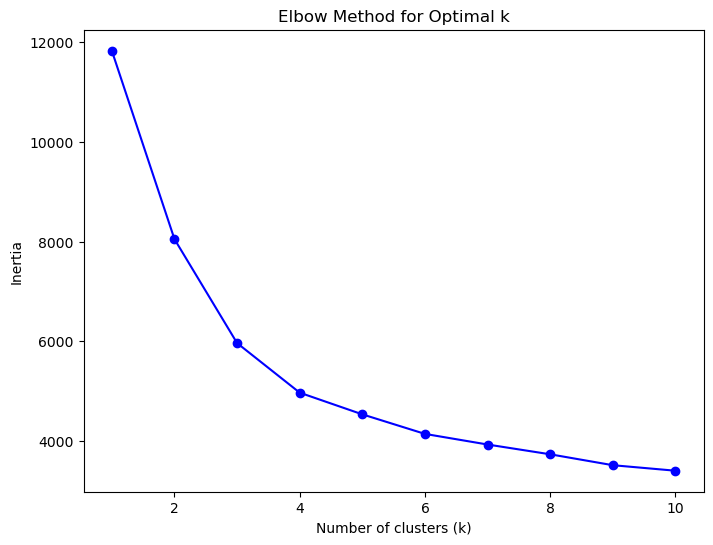

In [4]:
X = df.values  
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [5]:
kmeans = KMeans(n_clusters=3,random_state=45)
kmeans.fit(X)
kmeans.labels_
df['cluster'] = pd.DataFrame(kmeans.labels_)

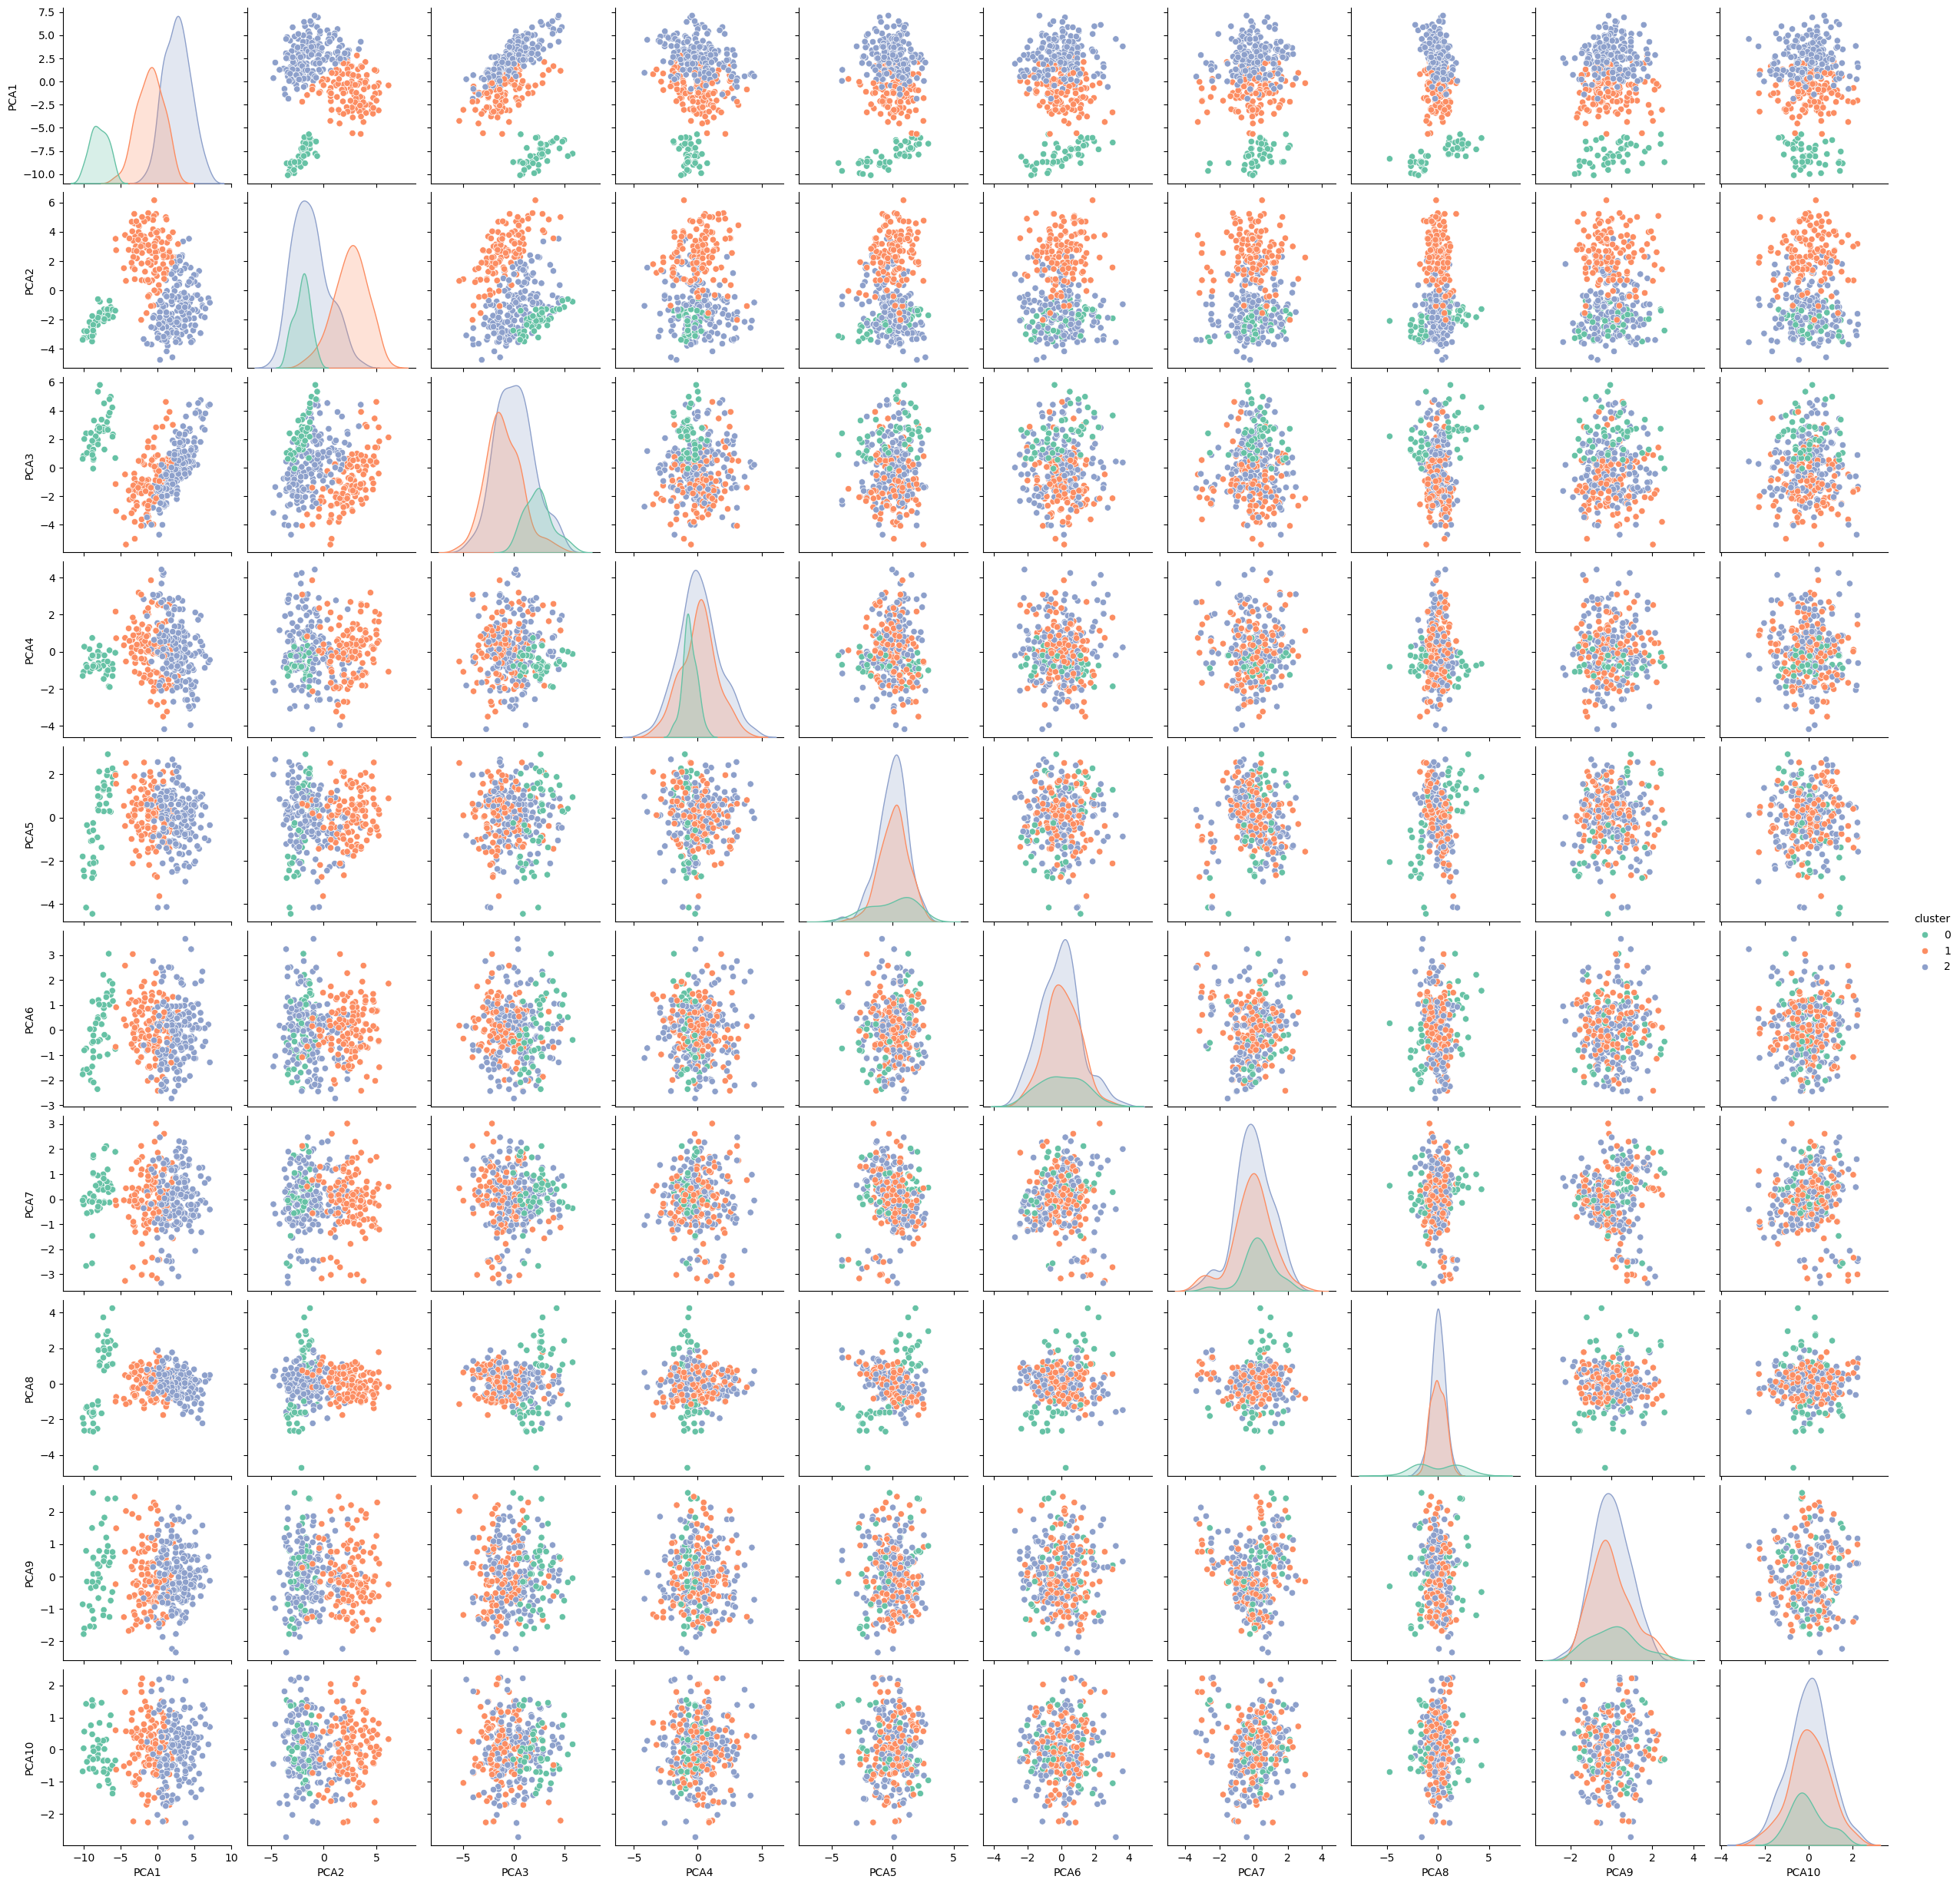

In [6]:
pca = PCA(n_components=10)
pca_components = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_components,columns=[f'PCA{i}' for i in range(1, 11)])
pca_df['cluster'] = kmeans.labels_

sns.pairplot(pca_df,hue='cluster',diag_kind='kde',palette='Set2')
plt.show()

In [7]:
X = df.drop("cluster", axis=1)
y = df["cluster"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 1. Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_r2 = r2_score(y_train, lr.predict(X_train))
lr_test_r2 = r2_score(y_test, lr.predict(X_test))

### 2. RandomForestRegressor

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=45)
rf.fit(X_train, y_train)
rf_train_r2 = r2_score(y_train, rf.predict(X_train))
rf_test_r2 = r2_score(y_test, rf.predict(X_test))

### 3. KMeans

In [10]:
kmeans = KMeans(n_clusters=3, random_state=45)
k_labels = kmeans.fit_predict(X)
k_sil = silhouette_score(X, k_labels)

### 4. MiniBatchKMeans

In [11]:
mbk = MiniBatchKMeans(n_clusters=3, random_state=45, batch_size=100)
mbk_labels = mbk.fit_predict(X)
mbk_sil = silhouette_score(X, mbk_labels)

## Final Result

In [12]:
results = [["Linear Regression", lr_train_r2, lr_test_r2, None],
    ["Random Forest", rf_train_r2, rf_test_r2, None],
    ["KMeans", None, None, k_sil],
    ["MiniBatchKMeans", None, None, mbk_sil],]

results_df = pd.DataFrame(results,columns=["Model", "Train R2", "Test R2", "Silhouette Score"])
results_df

,Model,Train R2,Test R2,Silhouette Score
0,Linear Regression,0.889310,0.829440,NaN
1,Random Forest,0.991573,0.937057,NaN
2,KMeans,NaN,NaN,0.284686
3,MiniBatchKMeans,NaN,NaN,0.183264
